In [5]:
from pathlib import Path
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
print(nk.__version__)

header_files = list(Path("data").rglob("*.hea"))

print("Number of ECG records found:", len(header_files))
print("First record:", header_files[0])

0.2.13
Number of ECG records found: 67028
First record: data/ptbxl_wfdb/00000/00568_lr.hea


In [12]:
def extract_ecg_features(ecg_signal, sampling_rate):
    cleaned = nk.ecg_clean(ecg_signal,sampling_rate=sampling_rate)

    _, info = nk.ecg_peaks(cleaned,sampling_rate=sampling_rate)

    rpeaks = info["ECG_R_Peaks"]

    rr_intervals_ms = (np.diff(rpeaks) / sampling_rate) * 1000

    heart_rate = 60000 / rr_intervals_ms

    mean_rr = np.mean(rr_intervals_ms)

    sdnn = np.std(rr_intervals_ms,ddof=1)

    rmssd = np.sqrt(np.mean(np.diff(rr_intervals_ms) ** 2))

    mean_heart_rate = np.mean(heart_rate)

    _, waves = nk.ecg_delineate(
        cleaned,
        rpeaks,
        sampling_rate=sampling_rate,
        method="dwt"
    )

    qrs_durations = []

    r_onsets = waves.get("ECG_R_Onsets", [])
    r_offsets = waves.get("ECG_R_Offsets", [])

    for onset, offset in zip(r_onsets, r_offsets):
        if onset is None or offset is None:
            continue

        if np.isnan(onset) or np.isnan(offset):
            continue

        duration = ((offset - onset) / sampling_rate) * 1000

        if 40 <= duration <= 300:
            qrs_durations.append(duration)

    mean_qrs_duration = (
        np.median(qrs_durations)
        if len(qrs_durations) > 0
        else np.nan
    )

    signal_mean = np.mean(cleaned)
    signal_std = np.std(cleaned)
    signal_max = np.max(cleaned)
    signal_min = np.min(cleaned)

    features = {
        "mean_rr_ms": mean_rr,
        "sdnn_ms": sdnn,
        "rmssd_ms": rmssd,
        "heart_rate_bpm": mean_heart_rate,
        "qrs_duration_ms": mean_qrs_duration,
        "signal_mean": signal_mean,
        "signal_std": signal_std,
        "signal_max": signal_max,
        "signal_min": signal_min
    }

    return features

In [2]:
from collections import Counter

dataset_folders = Counter(
    path.relative_to("data").parts[0]
    for path in header_files
)

print("Top-level folders inside data:")
for folder, count in dataset_folders.items():
    print(f"{folder}: {count} header files")

Top-level folders inside data:
ptbxl_wfdb: 21799 header files
samitrop_wfdb: 1631 header files
ptb-xl-1.0.3: 43598 header files


In [4]:
samitrop_headers = sorted(Path("data/samitrop_wfdb").rglob("*.hea"))
ptbxl_headers = sorted(Path("data/ptbxl_wfdb").rglob("*.hea"))

print("SaMi-Trop records:", len(samitrop_headers))
print("PTB-XL records:", len(ptbxl_headers))

for dataset_name, files in [
    ("SaMi-Trop", samitrop_headers),
    ("PTB-XL", ptbxl_headers)
]:
    sample_header_path = files[0]
    record_path = str(sample_header_path.with_suffix(""))
    header = wfdb.rdheader(record_path)

    print()
    print(dataset_name)
    print("Header file:", sample_header_path)
    print("Record name:", header.record_name)
    print("Sampling rate:", header.fs)
    print("Signal names:", header.sig_name)
    print("Comments:", header.comments)

SaMi-Trop records: 1631
PTB-XL records: 21799

SaMi-Trop
Header file: data/samitrop_wfdb/100726.hea
Record name: 100726
Sampling rate: 400
Signal names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Comments: ['Age: 64', 'Sex: Male', 'Chagas label: True', 'Source: SaMi-Trop']

PTB-XL
Header file: data/ptbxl_wfdb/00000/00001_lr.hea
Record name: 00001_lr
Sampling rate: 100
Signal names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Comments: ['Age: 56', 'Sex: Female', 'Chagas label: False', 'Source: PTB-XL']


In [6]:
metadata_files = list(Path("data").rglob("ptbxl_database.csv"))

print("Metadata files found:", metadata_files)

ptbxl_metadata = pd.read_csv(metadata_files[0])

print("Columns:", ptbxl_metadata.columns.tolist())
print(ptbxl_metadata[["ecg_id", "patient_id", "filename_lr"]].head())

print("Number of ECG records:", len(ptbxl_metadata))
print("Number of unique patients:", ptbxl_metadata["patient_id"].nunique())
print(
    "Repeated patient records:",
    ptbxl_metadata["patient_id"].duplicated().sum()
)

Metadata files found: [PosixPath('data/ptb-xl-1.0.3/ptbxl_database.csv')]
Columns: ['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']
   ecg_id  patient_id                filename_lr
0       1     15709.0  records100/00000/00001_lr
1       2     13243.0  records100/00000/00002_lr
2       3     20372.0  records100/00000/00003_lr
3       4     17014.0  records100/00000/00004_lr
4       5     17448.0  records100/00000/00005_lr
Number of ECG records: 21799
Number of unique patients: 18869
Repeated patient records: 2930


In [7]:
ptbxl_metadata["patient_id"] = ptbxl_metadata["patient_id"].astype("Int64")

ptbxl_patient_lookup = dict(
    zip(
        ptbxl_metadata["ecg_id"],
        ptbxl_metadata["patient_id"]
    )
)

sample_path = ptbxl_headers[0]

ecg_id = int(sample_path.stem.replace("_lr", ""))
patient_id = ptbxl_patient_lookup[ecg_id]

print("File:", sample_path.name)
print("ECG ID:", ecg_id)
print("Patient ID:", patient_id)

File: 00001_lr.hea
ECG ID: 1
Patient ID: 15709


In [ ]:
def get_header_info(header):
    info = {}

    for comment in header.comments:
        if ":" in comment:
            key, value = comment.split(":", 1)
            info[key.strip().lower()] = value.strip()

    age = pd.to_numeric(info.get("age"), errors="coerce")
    sex = info.get("sex", "Unknown")

    chagas_value = info.get("chagas label", "False").lower()
    label = 1 if chagas_value == "true" else 0

    return age, sex, label


In [9]:
samitrop_header = wfdb.rdheader(
    str(samitrop_headers[0].with_suffix(""))
)

ptbxl_header = wfdb.rdheader(
    str(ptbxl_headers[0].with_suffix(""))
)

print("SaMi-Trop:", get_header_info(samitrop_header))
print("PTB-XL:", get_header_info(ptbxl_header))


SaMi-Trop: (np.int64(64), 'Male', 1)
PTB-XL: (np.int64(56), 'Female', 0)


In [10]:
def process_record(header_path, dataset):
    record_path = str(header_path.with_suffix(""))
    record = wfdb.rdrecord(record_path)

    lead_ii_index = record.sig_name.index("II")
    lead_ii_signal = record.p_signal[:, lead_ii_index]

    features = extract_ecg_features(
        lead_ii_signal,
        record.fs
    )

    header = wfdb.rdheader(record_path)
    age, sex, label = get_header_info(header)

    record_id = header.record_name

    if dataset == "PTB-XL":
        ecg_id = int(header_path.stem.replace("_lr", ""))
        patient_id = ptbxl_patient_lookup[ecg_id]
        patient_id = f"ptbxl_{patient_id}"
    else:
        patient_id = f"samitrop_{record_id}"

    features["record_id"] = record_id
    features["patient_id"] = patient_id
    features["dataset"] = dataset
    features["age"] = age
    features["sex"] = sex
    features["label"] = label

    return features

In [13]:
samitrop_test = process_record(
    samitrop_headers[0],
    "SaMi-Trop"
)

ptbxl_test = process_record(
    ptbxl_headers[0],
    "PTB-XL"
)

test_df = pd.DataFrame([
    samitrop_test,
    ptbxl_test
])

test_df

,mean_rr_ms,sdnn_ms,rmssd_ms,heart_rate_bpm,qrs_duration_ms,signal_mean,signal_std,signal_max,signal_min,record_id,patient_id,dataset,age,sex,label
0,1109.583333,22.550868,31.898276,54.092802,132.5,0.000231,0.103140,0.602718,-0.382984,100726,samitrop_100726,SaMi-Trop,64,Male,1
1,940.000000,20.000000,26.457513,63.855440,150.0,0.002432,0.072941,0.321446,-0.084728,00001_lr,ptbxl_15709,PTB-XL,56,Female,0


In [14]:
def process_many_records(header_paths, dataset, target_successes=None):
    rows = []
    failed = []

    for number, header_path in enumerate(header_paths, start=1):
        try:
            row = process_record(header_path, dataset)
            rows.append(row)

        except Exception as error:
            failed.append({
                "dataset": dataset,
                "record": header_path.stem,
                "error": str(error)
            })

        if number % 100 == 0:
            print(
                dataset,
                "- checked:", number,
                "- successful:", len(rows),
                "- failed:", len(failed)
            )

        if target_successes is not None and len(rows) >= target_successes:
            break

    return rows, failed

In [15]:
test_rows, test_failures = process_many_records(
    samitrop_headers[:10],
    "SaMi-Trop"
)

print("Successful:", len(test_rows))
print("Failed:", len(test_failures))

pd.DataFrame(test_rows).head()

Successful: 10
Failed: 0


,mean_rr_ms,sdnn_ms,rmssd_ms,heart_rate_bpm,qrs_duration_ms,signal_mean,signal_std,signal_max,signal_min,record_id,patient_id,dataset,age,sex,label
0,1109.583333,22.550868,31.898276,54.092802,132.5,0.000231,0.103140,0.602718,-0.382984,100726,samitrop_100726,SaMi-Trop,64,Male,1
1,1046.666667,7.011895,12.399597,57.326992,220.0,-0.000946,0.106088,0.476027,-0.458143,101191,samitrop_101191,SaMi-Trop,49,Male,1
2,949.285714,5.721721,6.373774,63.207383,115.0,0.003463,0.214373,0.894476,-0.502218,101193,samitrop_101193,SaMi-Trop,68,Female,1
3,985.416667,10.418333,8.587782,60.893648,182.5,0.001000,0.126772,0.538971,-0.332201,101282,samitrop_101282,SaMi-Trop,70,Female,1
4,918.571429,12.571226,16.007811,65.329221,175.0,0.001624,0.286154,1.751559,-0.493912,101842,samitrop_101842,SaMi-Trop,49,Female,1


In [16]:
rng = np.random.default_rng(42)

ptbxl_random_order = [
    ptbxl_headers[index]
    for index in rng.permutation(len(ptbxl_headers))
]

samitrop_rows, samitrop_failures = process_many_records(
    samitrop_headers,
    "SaMi-Trop"
)

ptbxl_rows, ptbxl_failures = process_many_records(
    ptbxl_random_order,
    "PTB-XL",
    target_successes=500
)

feature_df = pd.DataFrame(samitrop_rows + ptbxl_rows)

failed_df = pd.DataFrame(
    samitrop_failures + ptbxl_failures,
    columns=["dataset", "record", "error"]
)

feature_df.to_csv("week5_ecg_features.csv", index=False)
failed_df.to_csv("week5_failed_records.csv", index=False)

print("Total successful records:", len(feature_df))
print("SaMi-Trop successful:", len(samitrop_rows))
print("PTB-XL successful:", len(ptbxl_rows))
print("Total failed records:", len(failed_df))
print("Saved week5_ecg_features.csv")
print("Saved week5_failed_records.csv")

/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/neuroki

SaMi-Trop - checked: 100 - successful: 98 - failed: 2
SaMi-Trop - checked: 200 - successful: 198 - failed: 2


/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/neuroki

SaMi-Trop - checked: 300 - successful: 296 - failed: 4


/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/neuroki

...

SaMi-Trop - checked: 1400 - successful: 1371 - failed: 29
SaMi-Trop - checked: 1500 - successful: 1471 - failed: 29


/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/neuroki

SaMi-Trop - checked: 1600 - successful: 1569 - failed: 31


/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/cinc2025/lib/python3.11/site-packages/neurokit2/signal/signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(


PTB-XL - checked: 100 - successful: 99 - failed: 1
PTB-XL - checked: 200 - successful: 199 - failed: 1
PTB-XL - checked: 300 - successful: 299 - failed: 1
PTB-XL - checked: 400 - successful: 399 - failed: 1
PTB-XL - checked: 500 - successful: 499 - failed: 1
Total successful records: 2100
SaMi-Trop successful: 1600
PTB-XL successful: 500
Total failed records: 32
Saved week5_ecg_features.csv
Saved week5_failed_records.csv


In [17]:
feature_df = pd.read_csv("week5_ecg_features.csv")

print("Dataset shape:", feature_df.shape)
print()
print("Records by dataset:")
print(feature_df["dataset"].value_counts())

print()
print("Labels:")
print(feature_df["label"].value_counts())

print()
print("Sex values:")
print(feature_df["sex"].value_counts(dropna=False))

print()
print("Missing values:")
print(feature_df.isna().sum())

print()
print("Repeated patient IDs:")
print(feature_df["patient_id"].duplicated().sum())

feature_df.head()

Dataset shape: (2100, 15)

Records by dataset:
dataset
SaMi-Trop    1600
PTB-XL        500
Name: count, dtype: int64

Labels:
label
1    1600
0     500
Name: count, dtype: int64

Sex values:
sex
Female    1338
Male       762
Name: count, dtype: int64

Missing values:
mean_rr_ms          0
sdnn_ms             0
rmssd_ms            0
heart_rate_bpm      0
qrs_duration_ms    39
signal_mean         0
signal_std          0
signal_max          0
signal_min          0
record_id           0
patient_id          0
dataset             0
age                 0
sex                 0
label               0
dtype: int64

Repeated patient IDs:
1


,mean_rr_ms,sdnn_ms,rmssd_ms,heart_rate_bpm,qrs_duration_ms,signal_mean,signal_std,signal_max,signal_min,record_id,patient_id,dataset,age,sex,label
0,1109.583333,22.550868,31.898276,54.092802,132.5,0.000231,0.103140,0.602718,-0.382984,100726,samitrop_100726,SaMi-Trop,64,Male,1
1,1046.666667,7.011895,12.399597,57.326992,220.0,-0.000946,0.106088,0.476027,-0.458143,101191,samitrop_101191,SaMi-Trop,49,Male,1
2,949.285714,5.721721,6.373774,63.207383,115.0,0.003463,0.214373,0.894476,-0.502218,101193,samitrop_101193,SaMi-Trop,68,Female,1
3,985.416667,10.418333,8.587782,60.893648,182.5,0.001000,0.126772,0.538971,-0.332201,101282,samitrop_101282,SaMi-Trop,70,Female,1
4,918.571429,12.571226,16.007811,65.329221,175.0,0.001624,0.286154,1.751559,-0.493912,101842,samitrop_101842,SaMi-Trop,49,Female,1


In [18]:
missing_counts = feature_df.isna().sum()
print("Columns with missing values:")
print(missing_counts[missing_counts > 0])

repeated_patients = feature_df[
    feature_df["patient_id"].duplicated(keep=False)
].sort_values("patient_id")

print()
print("Repeated patient rows:")
repeated_patients[
    ["record_id", "patient_id", "dataset", "age", "sex", "label"]
]

Columns with missing values:
qrs_duration_ms    39
dtype: int64

Repeated patient rows:


,record_id,patient_id,dataset,age,sex,label
1669,09012_lr,ptbxl_14981,PTB-XL,54,Male,0
1905,09295_lr,ptbxl_14981,PTB-XL,54,Male,0


In [19]:
from sklearn.model_selection import GroupShuffleSplit

feature_columns = [
    "mean_rr_ms",
    "sdnn_ms",
    "rmssd_ms",
    "heart_rate_bpm",
    "qrs_duration_ms",
    "signal_mean",
    "signal_std",
    "signal_max",
    "signal_min",
    "age",
    "sex"
]

X = feature_df[feature_columns].copy()
y = feature_df["label"].copy()
groups = feature_df["patient_id"].copy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_indices, test_indices = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]

y_train = y.iloc[train_indices]
y_test = y.iloc[test_indices]

groups_train = groups.iloc[train_indices]
groups_test = groups.iloc[test_indices]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print()
print("Training labels:")
print(y_train.value_counts())

print()
print("Testing labels:")
print(y_test.value_counts())

patient_overlap = set(groups_train) & set(groups_test)
print()
print("Patients appearing in both sets:", len(patient_overlap))

Training rows: 1680
Testing rows: 420

Training labels:
label
1    1288
0     392
Name: count, dtype: int64

Testing labels:
label
1    312
0    108
Name: count, dtype: int64

Patients appearing in both sets: 0


In [20]:
assert len(X_train) + len(X_test) == len(feature_df)
assert set(groups_train).isdisjoint(set(groups_test))
assert set(y_train.unique()) == {0, 1}
assert set(y_test.unique()) == {0, 1}

print("Split checks passed.")

Split checks passed.


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

numeric_features = [
    "mean_rr_ms",
    "sdnn_ms",
    "rmssd_ms",
    "heart_rate_bpm",
    "qrs_duration_ms",
    "signal_mean",
    "signal_std",
    "signal_max",
    "signal_min",
    "age"
]

categorical_features = ["sex"]

numeric_for_logistic = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_for_forest = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_processing = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

logistic_preprocessor = ColumnTransformer([
    ("numeric", numeric_for_logistic, numeric_features),
    ("categorical", categorical_processing, categorical_features)
])

forest_preprocessor = ColumnTransformer([
    ("numeric", numeric_for_forest, numeric_features),
    ("categorical", categorical_processing, categorical_features)
])

logistic_model = Pipeline([
    ("preprocessor", logistic_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

random_forest_model = Pipeline([
    ("preprocessor", forest_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

print("Models created.")

Models created.


In [22]:
logistic_model.fit(X_train, y_train)
print("Logistic Regression trained.")

random_forest_model.fit(X_train, y_train)
print("Random Forest trained.")

Logistic Regression trained.
Random Forest trained.


In [23]:
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    f1_score
)

def challenge_score(y_true, probabilities, alpha=0.05):
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    number_selected = int(np.floor(alpha * len(y_true)))

    if number_selected == 0:
        return 0.0

    sorted_probabilities = np.sort(probabilities)[::-1]
    cutoff_probability = sorted_probabilities[number_selected - 1]

    above_cutoff = probabilities > cutoff_probability
    tied_at_cutoff = probabilities == cutoff_probability

    selected_above = above_cutoff.sum()
    remaining_places = number_selected - selected_above

    positives_above = y_true[above_cutoff].sum()

    number_tied = tied_at_cutoff.sum()
    positives_tied = y_true[tied_at_cutoff].sum()

    expected_tied_positives = (
        remaining_places * positives_tied / number_tied
    )

    total_positives = y_true.sum()

    return (
        positives_above + expected_tied_positives
    ) / total_positives


def evaluate_model(model, X_test, y_test):
    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)

    results = {
        "AUROC": roc_auc_score(y_test, probabilities),
        "Sensitivity": recall_score(
            y_test,
            predictions,
            pos_label=1
        ),
        "Specificity": recall_score(
            y_test,
            predictions,
            pos_label=0
        ),
        "F1": f1_score(y_test, predictions),
        "Challenge Score": challenge_score(
            y_test,
            probabilities
        )
    }

    return results, probabilities, predictions

In [24]:
logistic_results, logistic_probabilities, logistic_predictions = (
    evaluate_model(logistic_model, X_test, y_test)
)

forest_results, forest_probabilities, forest_predictions = (
    evaluate_model(random_forest_model, X_test, y_test)
)

print("Logistic Regression:")
print(logistic_results)

print()
print("Random Forest:")
print(forest_results)

Logistic Regression:
{'AUROC': np.float64(0.8579653371320037), 'Sensitivity': 0.7467948717948718, 'Specificity': 0.8425925925925926, 'F1': 0.8291814946619217, 'Challenge Score': np.float64(0.0673076923076923)}

Random Forest:
{'AUROC': np.float64(0.9191892212725545), 'Sensitivity': 0.9391025641025641, 'Specificity': 0.6296296296296297, 'F1': 0.9085271317829458, 'Challenge Score': np.float64(0.0673076923076923)}


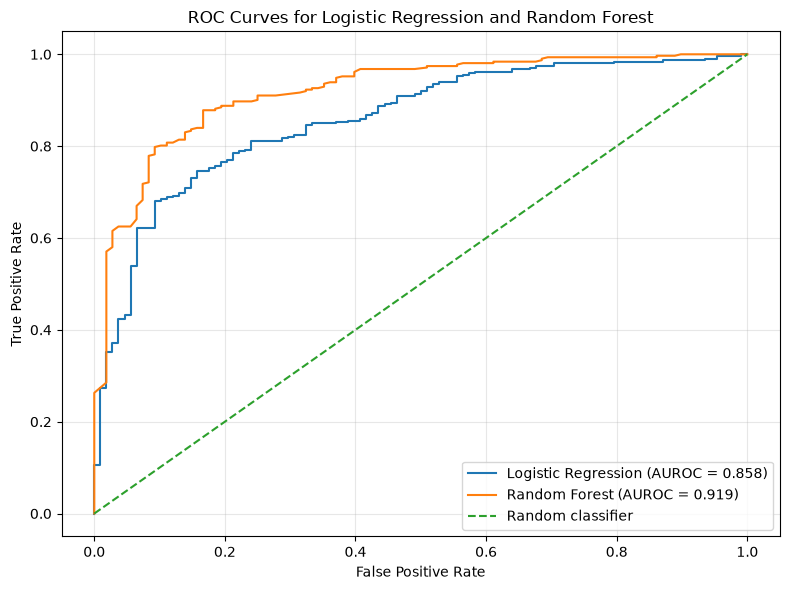

In [25]:
from sklearn.metrics import roc_curve

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

forest_fpr, forest_tpr, _ = roc_curve(
    y_test,
    forest_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUROC = {logistic_results['AUROC']:.3f})"
)

plt.plot(
    forest_fpr,
    forest_tpr,
    label=f"Random Forest (AUROC = {forest_results['AUROC']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Logistic Regression and Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "week5_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

            Feature  Importance
6        signal_std    0.216306
8        signal_min    0.194748
7        signal_max    0.093952
3    heart_rate_bpm    0.076500
0        mean_rr_ms    0.075114
5       signal_mean    0.070073
9               age    0.068752
2          rmssd_ms    0.066885
1           sdnn_ms    0.056720
4   qrs_duration_ms    0.056155
10       sex_Female    0.013308
11         sex_Male    0.011487


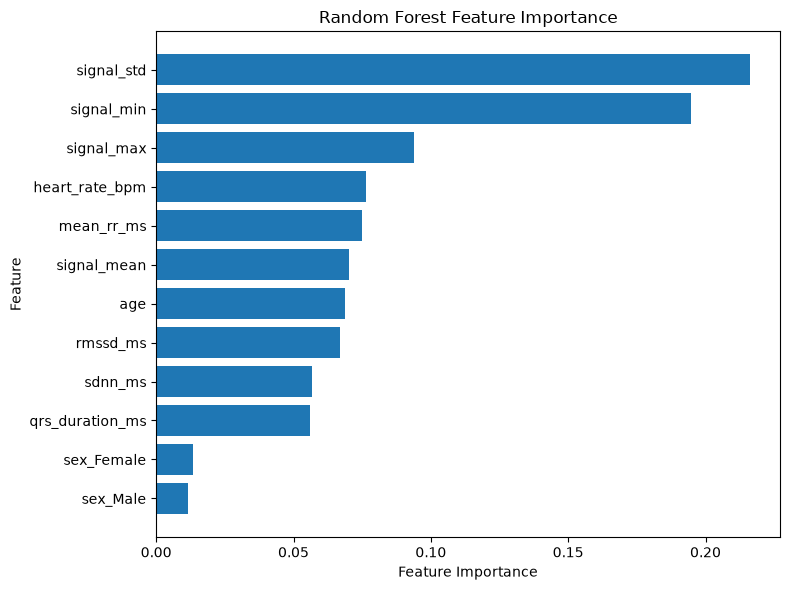

In [26]:
feature_names = random_forest_model[
    "preprocessor"
].get_feature_names_out()

feature_names = [
    name.replace("numeric__", "").replace("categorical__", "")
    for name in feature_names
]

feature_importances = random_forest_model[
    "classifier"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(
    "Importance",
    ascending=False
)

print(importance_df)

plt.figure(figsize=(8, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()

plt.savefig(
    "week5_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
results_table = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **logistic_results
    },
    {
        "Model": "Random Forest",
        **forest_results
    }
])

results_table = results_table.round(4)

results_table.to_csv(
    "week5_model_results.csv",
    index=False
)

results_table

,Model,AUROC,Sensitivity,Specificity,F1,Challenge Score
0,Logistic Regression,0.8580,0.7468,0.8426,0.8292,0.0673
1,Random Forest,0.9192,0.9391,0.6296,0.9085,0.0673


In [29]:
import shutil

official_check_folder = Path("../week5_official_check")

if official_check_folder.exists():
    shutil.rmtree(official_check_folder)

label_folder = official_check_folder / "labels"
logistic_output_folder = official_check_folder / "logistic_outputs"
forest_output_folder = official_check_folder / "forest_outputs"

label_folder.mkdir(parents=True)
logistic_output_folder.mkdir()
forest_output_folder.mkdir()

print("Official evaluation folders created.")

Official evaluation folders created.


In [30]:
official_test = feature_df.iloc[test_indices][
    ["record_id", "patient_id", "label"]
].reset_index(drop=True)

official_test["evaluation_id"] = [
    f"record_{i:04d}"
    for i in range(len(official_test))
]

official_test["logistic_probability"] = logistic_probabilities
official_test["logistic_prediction"] = logistic_predictions

official_test["forest_probability"] = forest_probabilities
official_test["forest_prediction"] = forest_predictions

print("Rows prepared:", len(official_test))
official_test.head()

Rows prepared: 420


,record_id,patient_id,label,evaluation_id,logistic_probability,logistic_prediction,forest_probability,forest_prediction
0,104023,samitrop_104023,1,record_0000,0.190198,0,0.633333,1
1,105406,samitrop_105406,1,record_0001,0.212841,0,0.763333,1
2,108586,samitrop_108586,1,record_0002,0.529301,1,0.686667,1
3,112145,samitrop_112145,1,record_0003,0.889725,1,0.993333,1
4,119662,samitrop_119662,1,record_0004,0.216645,0,0.460000,0


In [31]:
for _, row in official_test.iterrows():
    evaluation_id = row["evaluation_id"]

    true_label = bool(int(row["label"]))
    logistic_label = bool(int(row["logistic_prediction"]))
    forest_label = bool(int(row["forest_prediction"]))

    label_text = (
        f"{evaluation_id} 0 100 0\n"
        f"# Chagas label: {true_label}\n"
    )

    logistic_text = (
        f"{evaluation_id}\n"
        f"# Chagas label: {logistic_label}\n"
        f"# Chagas probability: {row['logistic_probability']}\n"
    )

    forest_text = (
        f"{evaluation_id}\n"
        f"# Chagas label: {forest_label}\n"
        f"# Chagas probability: {row['forest_probability']}\n"
    )

    (label_folder / f"{evaluation_id}.hea").write_text(label_text)

    (
        logistic_output_folder / f"{evaluation_id}.txt"
    ).write_text(logistic_text)

    (
        forest_output_folder / f"{evaluation_id}.txt"
    ).write_text(forest_text)

print("Label files:", len(list(label_folder.glob("*.hea"))))
print(
    "Logistic files:",
    len(list(logistic_output_folder.glob("*.txt")))
)
print(
    "Random Forest files:",
    len(list(forest_output_folder.glob("*.txt")))
)

Label files: 420
Logistic files: 420
Random Forest files: 420


 Summary:

Overall, the Random Forest performed better than Logistic Regression. It got a higher AUROC (0.919 compared with 0.858), sensitivity (0.939 compared with 0.747), and F1 score (0.909 compared with 0.829). This implies that the Random Forest was able to learn nonlinear relationships between the ECG features better. Whereas, Logistic Regression had higher specificity (0.843 compared with 0.630), meaning it was better at correctly identifying negative cases. Both models achieved the same Challenge score of 0.067 because all 21 test records in the top 5% of predicted risk were true positive cases. The Random Forest relied most heavily on signal standard deviation, minimum amplitude, and maximum amplitude. QRS duration was useful but was not one of the strongest features. One limitation is that all the positive records came from SaMi-Trop while all the negative records came from PTB-XL. This could have affected the model's performance by depending on the difference between the datasets instead of the Chagas disease itself. The Challenge scores calculated in the notebook matched the official evaluate_model.py results.